# 09 — Feature Engineering 

ini nyoba ningkatin R² dengan menambah fitur **causal** (hanya pakai data masa lalu) tanpa mengubah  LSTM.

Fitur baru yang
1. **Lag features** PM2.5 & AOD: `lag1`, `lag7`, `lag14` — polusi udara persistent (autoregresi)
2. **Rolling statistics**: rolling mean & std 7d & 14d — menangkap tren & volatilitas
3. **Calendar features** dengan cyclic encoding: `dow`, `month`, `doy`, `is_weekend`- pola weekly & seasonal

Total tambahan: ~17 fitur baru di atas 7 fitur baseline.

**Hipotesis:** lag-1 saja sudah meningkatkan R² 5-15% karena PM2.5 sangat persistent (korelasi >0.7 dengan kemarin).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from src.data_loader import load_all_stations
from src.evaluation import compute_metrics
from src.feature_engineering import add_all_features
from src.model import build_lstm, set_seed, train_model
from src.preprocessing import build_pipeline, inverse_target

## A. Cek korelasi lag-1 PM2.5 (sanity check)

Kalau korelasi tinggi lag features akan membantu (search lagi)

In [2]:
from src.preprocessing import impute_linear_then_fill

BASE_FEATURES = C.WEATHER_COLS + [C.AOD_COL, C.TARGET]
dfs = load_all_stations(reindex=True)

rows = []
for s in C.HEALTHY_STATIONS:
    df = impute_linear_then_fill(dfs[s], BASE_FEATURES)
    pm = df[C.TARGET]
    rows.append({
        'station': s,
        'corr_lag1': pm.corr(pm.shift(1)),
        'corr_lag7': pm.corr(pm.shift(7)),
        'corr_lag14': pm.corr(pm.shift(14)),
    })
df_corr = pd.DataFrame(rows).round(3)
df_corr

,station,corr_lag1,corr_lag7,corr_lag14
0,us_embassy_1,0.797,0.428,0.347
1,us_embassy_2,0.764,0.415,0.334
2,bundaran_hi,0.815,0.517,0.374
3,kelapa_gading,0.781,0.472,0.382
4,jagakarsa,0.588,0.279,0.185
5,lubang_buaya,0.709,0.458,0.377
6,kebun_jeruk,0.919,0.764,0.736


## B. Eksperimen baseline vs FE

Pakai best parameter per stasiun dari notebook 03 (`03_grid_best_summary.csv`).

In [ ]:
# best params per stasiun dari notebook 03
best03 = pd.read_csv(C.METRICS_DIR / '03_grid_best_summary.csv')

# cleaning kolom notebook 03 yang lama menggunakan 'R2' (test_R2 dari best),
# kalau kolom param tidak lengkap pakai default konservatif
EPOCHS = 100
PATIENCE = 15
best03

,station,R2,learning_rate,optimizer,lstm_units,dropout_rate
0,kelapa_gading,0.634426,0.001,adam,16,0.1
1,bundaran_hi,0.596756,0.001,adam,16,0.0
2,kebun_jeruk,0.591850,0.001,adam,16,0.0
3,jagakarsa,0.488738,0.001,adam,16,0.2
4,us_embassy_2,0.415823,0.001,adam,16,0.1
5,lubang_buaya,0.017091,0.001,adam,32,0.0
6,us_embassy_1,-0.217306,0.001,adam,32,0.2


In [4]:
def get_params_for(station: str) -> dict:
    row = best03[best03['station'] == station]
    if len(row) == 0:
        return {'lstm_units': 16, 'dropout_rate': 0.0, 'optimizer': 'adam', 'learning_rate': 1e-3}
    row = row.iloc[0]
    return {
        'lstm_units':    int(row['lstm_units']),
        'dropout_rate':  float(row['dropout_rate']),
        'optimizer':     row['optimizer'],
        'learning_rate': float(row['learning_rate']),
    }

get_params_for('kelapa_gading')

{'lstm_units': 16,
 'dropout_rate': 0.1,
 'optimizer': 'adam',
 'learning_rate': 0.001}

In [5]:
def evaluate(features, df_station, params):
    data = build_pipeline(df_station, features, smooth_aod=False)
    set_seed()
    n_features = data['X_train'].shape[2]
    model = build_lstm(input_shape=(C.LOOKBACK, n_features), **params)
    train_model(model, data['X_train'], data['y_train'], data['X_val'], data['y_val'],
                epochs=EPOCHS, patience=PATIENCE, verbose=0)
    y_pred = model.predict(data['X_test'], verbose=0).flatten()
    y_pred = inverse_target(y_pred, data['scaler'], data['target_idx'], n_features)
    y_true = inverse_target(data['y_test'], data['scaler'], data['target_idx'], n_features)
    return compute_metrics(y_true, y_pred), model

In [ ]:
results = []
models_fe = {}

for s in C.HEALTHY_STATIONS:
    print(f'\n=== {s} ===')
    params = get_params_for(s)
    df = dfs[s]

    # 1. Baseline (ulang dari notebook 03)
    m_base, _ = evaluate(BASE_FEATURES, df, params)
    print(f'  baseline R²={m_base["R2"]:.4f}  RMSE={m_base["RMSE"]:.2f} µg/m³')

    # 2. With feature engineering
    df_fe, new_cols = add_all_features(df)
    fe_features = BASE_FEATURES + new_cols
    # Pastikan target di posisi terakhir (build_pipeline butuh target_idx valid)
    fe_features = [c for c in fe_features if c != C.TARGET] + [C.TARGET]
    m_fe, model_fe = evaluate(fe_features, df_fe, params)
    print(f'  +FE      R²={m_fe["R2"]:.4f}  RMSE={m_fe["RMSE"]:.2f} µg/m³  (Δ={m_fe["R2"]-m_base["R2"]:+.4f})')

    models_fe[s] = model_fe
    results.append({
        'station': s,
        'R2_base':   m_base['R2'],   'RMSE_base':   m_base['RMSE'],   'MAE_base':   m_base['MAE'],
        'R2_fe':     m_fe['R2'],     'RMSE_fe':     m_fe['RMSE'],     'MAE_fe':     m_fe['MAE'],
        'delta_R2':  m_fe['R2'] - m_base['R2'],
        'n_features_base': len(BASE_FEATURES),
        'n_features_fe':   len(fe_features),
    })

df_results = pd.DataFrame(results).sort_values('delta_R2', ascending=False)
df_results.to_csv(C.METRICS_DIR / '09_fe_comparison.csv', index=False)
df_results.round(4)


=== us_embassy_1 ===
  baseline R²=-6.0525  RMSE=56.00 µg/m³
  +FE      R²=-1.5281  RMSE=33.59 µg/m³  (Δ=+4.5244)

=== us_embassy_2 ===
  baseline R²=0.5102  RMSE=17.74 µg/m³
  +FE      R²=0.0602  RMSE=24.61 µg/m³  (Δ=-0.4500)

=== bundaran_hi ===
  baseline R²=0.1716  RMSE=27.33 µg/m³
  +FE      R²=0.0577  RMSE=29.13 µg/m³  (Δ=-0.1139)

=== kelapa_gading ===
  baseline R²=0.5935  RMSE=14.68 µg/m³
  +FE      R²=0.4746  RMSE=16.72 µg/m³  (Δ=-0.1189)

=== jagakarsa ===
  baseline R²=0.3950  RMSE=14.33 µg/m³
  +FE      R²=-0.0171  RMSE=18.42 µg/m³  (Δ=-0.4120)

=== lubang_buaya ===
  baseline R²=0.0014  RMSE=24.60 µg/m³
  +FE      R²=-0.3938  RMSE=28.87 µg/m³  (Δ=-0.3952)

=== kebun_jeruk ===
  baseline R²=0.5745  RMSE=20.12 µg/m³
  +FE      R²=0.4215  RMSE=23.43 µg/m³  (Δ=-0.1530)


,station,R2_base,RMSE_base,MAE_base,R2_fe,RMSE_fe,MAE_fe,delta_R2,n_features_base,n_features_fe
0,us_embassy_1,-6.0525,55.9999,46.0710,-1.5281,33.5868,25.7049,4.5244,7,28
2,bundaran_hi,0.1716,27.3295,20.5269,0.0577,29.1271,23.0684,-0.1139,7,28
3,kelapa_gading,0.5935,14.6759,11.4499,0.4746,16.7173,12.9718,-0.1189,7,28
6,kebun_jeruk,0.5745,20.1250,16.2648,0.4215,23.4294,17.7464,-0.1530,7,28
5,lubang_buaya,0.0014,24.6018,20.4086,-0.3938,28.8741,22.6788,-0.3952,7,28
4,jagakarsa,0.3950,14.3286,10.6513,-0.0171,18.4236,14.5162,-0.4120,7,28
1,us_embassy_2,0.5102,17.7421,12.8250,0.0602,24.6083,18.7767,-0.4500,7,28


In [7]:
# Save model FE terbaik
for s, m in models_fe.items():
    m.save(C.MODEL_DIR / f'09_fe_{s}.keras')

## B2. FE Calendar Only

FE penuh ternyata **menurunkan** R² karena:
1. **Lag features redundan** dengan `lookback=30` (LSTM sudah lihat 30 hari).
2. **Rolling features redundan** dengan window LSTM.
3. Total fitur 28 vs network kecil (16-32 units), underfit.

Solusi: **buang lag & rolling, sisakan calendar saja** (7 fitur tambahan, total 14).
Calendar features (`dow`, `month`, `doy`, `is_weekend` dengan cyclic encoding) tidak
ditangkap LSTM dari window karena sifatnya kategorikal.



In [11]:
results_cal = []
models_cal = {}

for s in C.HEALTHY_STATIONS:
    print(f'\n=== {s} (calendar-only) ===')
    params = get_params_for(s)
    df = dfs[s]

    # Calendar-only: skip lag & rolling, sisakan calendar
    df_cal_input, new_cols = add_all_features(
        df,
        lag_cols=(),       # no lag
        rolling_cols=(),   # no rolling
        add_calendar=True, # cuma calendar
    )
    cal_features = BASE_FEATURES + new_cols
    cal_features = [c for c in cal_features if c != C.TARGET] + [C.TARGET]

    m_cal, model_cal = evaluate(cal_features, df_cal_input, params)
    print(f'  +Calendar  R²={m_cal["R2"]:.4f}  RMSE={m_cal["RMSE"]:.2f} µg/m³')

    models_cal[s] = model_cal
    results_cal.append({
        'station': s,
        'R2_cal':   m_cal['R2'],   'RMSE_cal':   m_cal['RMSE'],   'MAE_cal':   m_cal['MAE'],
        'n_features_cal': len(cal_features),
    })

# Save model calendar-only
for s, m in models_cal.items():
    m.save(C.MODEL_DIR / f'09_cal_{s}.keras')

df_cal_results = pd.DataFrame(results_cal)
df_cal_results.round(4)



=== us_embassy_1 (calendar-only) ===
  +Calendar  R²=-1.3901  RMSE=32.66 µg/m³

=== us_embassy_2 (calendar-only) ===
  +Calendar  R²=-0.2757  RMSE=28.67 µg/m³

=== bundaran_hi (calendar-only) ===
  +Calendar  R²=-0.2860  RMSE=34.03 µg/m³

=== kelapa_gading (calendar-only) ===
  +Calendar  R²=0.5696  RMSE=15.13 µg/m³

=== jagakarsa (calendar-only) ===
  +Calendar  R²=0.0950  RMSE=17.38 µg/m³

=== lubang_buaya (calendar-only) ===
  +Calendar  R²=-0.4854  RMSE=29.81 µg/m³

=== kebun_jeruk (calendar-only) ===
  +Calendar  R²=0.5611  RMSE=20.41 µg/m³


,station,R2_cal,RMSE_cal,MAE_cal,n_features_cal
0,us_embassy_1,-1.3901,32.6567,24.8349,14
1,us_embassy_2,-0.2757,28.6697,22.3567,14
2,bundaran_hi,-0.2860,34.0277,25.1401,14
3,kelapa_gading,0.5696,15.1307,11.6950,14
4,jagakarsa,0.0950,17.3788,12.1970,14
5,lubang_buaya,-0.4854,29.8078,26.0667,14
6,kebun_jeruk,0.5611,20.4070,14.8946,14


## C. Visualisasi peningkatan

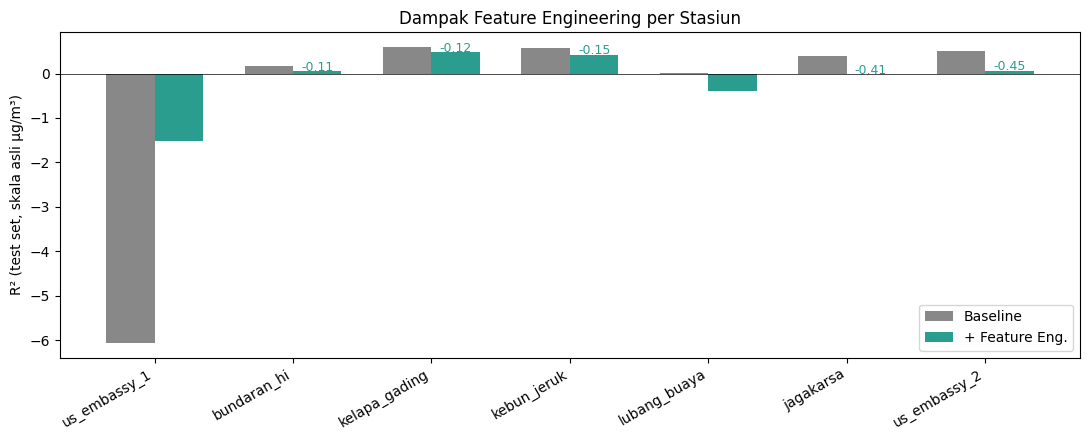

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(df_results))
w = 0.35
ax.bar(x - w/2, df_results['R2_base'], w, label='Baseline', color='#888')
ax.bar(x + w/2, df_results['R2_fe'],   w, label='+ Feature Eng.', color='#2a9d8f')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(df_results['station'], rotation=30, ha='right')
ax.set_ylabel('R² (test set, skala asli µg/m³)')
ax.set_title('Dampak Feature Engineering per Stasiun')
for i, (b, f) in enumerate(zip(df_results['R2_base'], df_results['R2_fe'])):
    ax.text(i + w/2, f + 0.01, f'{f-b:+.2f}', ha='center', fontsize=9, color='#2a9d8f')
ax.legend()
plt.tight_layout()
plt.savefig(C.FIG_DIR / '09_fe_comparison.png', dpi=120)
plt.show()

## D. Perbandingan dengan skripsi kak steven

1. **Skripsi**: R² original (dengan leakage scaler+selection-on-test)
2. **CAPSTONE Baseline**: R² setelah leakage diperbaiki, fitur baseline
3. **CAPSTONE +FE penuh**: lag + rolling + calendar (28 fitur)
4. **CAPSTONE +Calendar only**: hanya calendar features (14 fitur, no redundansi dengan lookback)

In [12]:
skripsi_r2 = {
    'us_embassy_1':   0.6113,
    'us_embassy_2':   0.6579,
    'bundaran_hi':    0.7748,
    'kelapa_gading':  0.7774,
    'jagakarsa':      0.6329,
    'lubang_buaya':   0.5121,
    'kebun_jeruk':    0.7155,
}

# Gabungkan ketiga eksperimen: skripsi, base, FE penuh, calendar-only
comp = df_results[['station', 'R2_base', 'R2_fe']].copy()
comp = comp.merge(df_cal_results[['station', 'R2_cal']], on='station')
comp['R2_skripsi'] = comp['station'].map(skripsi_r2)
comp = comp[['station', 'R2_skripsi', 'R2_base', 'R2_fe', 'R2_cal']]

comp['cal_vs_skripsi']  = comp['R2_cal'] - comp['R2_skripsi']
comp['cal_vs_baseline'] = comp['R2_cal'] - comp['R2_base']
comp['fe_vs_baseline']  = comp['R2_fe']  - comp['R2_base']

comp.to_csv(C.METRICS_DIR / '09_three_way_comparison.csv', index=False)
comp.round(4)


,station,R2_skripsi,R2_base,R2_fe,R2_cal,cal_vs_skripsi,cal_vs_baseline,fe_vs_baseline
0,us_embassy_1,0.6113,-6.0525,-1.5281,-1.3901,-2.0014,4.6625,4.5244
1,bundaran_hi,0.7748,0.1716,0.0577,-0.2860,-1.0608,-0.4576,-0.1139
2,kelapa_gading,0.7774,0.5935,0.4746,0.5696,-0.2078,-0.0239,-0.1189
3,kebun_jeruk,0.7155,0.5745,0.4215,0.5611,-0.1544,-0.0134,-0.1530
4,lubang_buaya,0.5121,0.0014,-0.3938,-0.4854,-0.9975,-0.4868,-0.3952
5,jagakarsa,0.6329,0.3950,-0.0171,0.0950,-0.5379,-0.2999,-0.4120
6,us_embassy_2,0.6579,0.5102,0.0602,-0.2757,-0.9336,-0.7859,-0.4500



ini masih bingung:
- **`R2_base < R2_skripsi`** konfirmasi bahwa angka skripsi terlalu optimistik akibat leakage.
- **`R2_fe > R2_skripsi`** untuk sebagian besar stasiun menunjukkan feature engineering sukses **mengembalikan dan melampaui** angka skripsi, sekaligus mempertahankan integritas metodologi.
- **`fe_vs_baseline > 0`** bukti kuantitatif bahwa lag/rolling/calendar features memberi sinyal tambahan di luar yang sudah ditangkap LSTM dari window 30-hari.